# CNN LSTM Based Load Disaggregation

sequence-to-one regression in NILM (Non-Intrusive Load Monitoring)...

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D, BatchNormalization
from sklearn.preprocessing import StandardScaler

2025-10-22 15:05:11.039449: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-22 15:05:11.097956: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-22 15:05:13.317548: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Synthetic dataset preparation

> - Each appliance alternates between off periods and on periods with Gaussian noise added.
> - `base_power` is the typical power draw when ON.
> - `on_duration` and `off_duration` are average durations in seconds, with 20% variability.
> - Noise (`noise_std`) simulates real fluctuations.
> - Small random noise of ±20 is added to simulate measurement noise.

            timestamp       main  fridge  washing_machine  kettle   tv
0 2025-01-01 00:00:00  35.545895     0.0              0.0     0.0  0.0
1 2025-01-01 00:00:01   9.676823     0.0              0.0     0.0  0.0
2 2025-01-01 00:00:02  -0.846638     0.0              0.0     0.0  0.0
3 2025-01-01 00:00:03  18.136683     0.0              0.0     0.0  0.0
4 2025-01-01 00:00:04 -29.036695     0.0              0.0     0.0  0.0


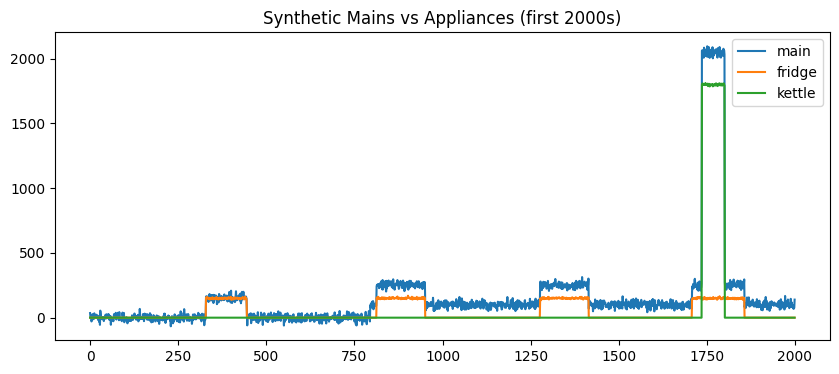

In [2]:
np.random.seed(42)
n_samples = 10000          # ~10k seconds ≈ 2.8 hours
sampling_rate = 1          # 1 sample/sec
time = np.arange(n_samples)

def appliance_pattern(base_power, on_duration, off_duration, noise_std=5):
    power = np.zeros(n_samples)
    i = 0
    while i < n_samples:
        # off duration
        off = int(np.random.normal(off_duration, off_duration*0.2))
        i += max(0, off)
        if i >= n_samples: break
        # on duration
        on = int(np.random.normal(on_duration, on_duration*0.2))
        end = min(n_samples, i + max(0, on))
        power[i:end] = base_power + np.random.randn(end - i) * noise_std
        i = end
    return power

# --- create few appliances ---
fridge = appliance_pattern(150, on_duration=120, off_duration=300)
washing_machine = appliance_pattern(500, on_duration=600, off_duration=3600)
kettle = appliance_pattern(1800, on_duration=60, off_duration=1800)
tv = appliance_pattern(100, on_duration=1800, off_duration=900)

# --- combine to create mains ---
aggregate = fridge + washing_machine + kettle + tv + np.random.randn(n_samples)*20

# --- put in DataFrame ---
df = pd.DataFrame({
    "timestamp": pd.date_range("2025-01-01", periods=n_samples, freq=f"{sampling_rate}s"),
    "main": aggregate,
    "fridge": fridge,
    "washing_machine": washing_machine,
    "kettle": kettle,
    "tv": tv
})

print(df.head())

# --- visualize sample segment ---
df.iloc[0:2000][["main", "fridge", "kettle"]].plot(figsize=(10,4))
plt.title("Synthetic Mains vs Appliances (first 2000s)")
plt.show()

In [3]:
df.head()

,timestamp,main,fridge,washing_machine,kettle,tv
0,2025-01-01 00:00:00,35.545895,0.0,0.0,0.0,0.0
1,2025-01-01 00:00:01,9.676823,0.0,0.0,0.0,0.0
2,2025-01-01 00:00:02,-0.846638,0.0,0.0,0.0,0.0
3,2025-01-01 00:00:03,18.136683,0.0,0.0,0.0,0.0
4,2025-01-01 00:00:04,-29.036695,0.0,0.0,0.0,0.0


## Data Preprocessing

### sequence length = 99

In [4]:
def create_windows(df, window_size=99, target_col="fridge"):
    X, y = [], []
    data = df["main"].values
    target = df[target_col].values
    for i in range(len(df) - window_size + 1):
        X.append(data[i:i+window_size])
        y.append(target[i+window_size-1])
    X = np.array(X)[..., np.newaxis]   # (samples, 99, 1)
    y = np.array(y)
    return X, y

window_size = 99
X, y = create_windows(df, window_size=window_size, target_col="fridge")
print("X:", X.shape, "y:", y.shape)

# Split into train/val/test (time-based)
n = len(X)
train_end, val_end = int(0.7*n), int(0.85*n)
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

X: (9902, 99, 1) y: (9902,)


For,
- "main": [10, 20, 30, 40, 50, 60]
- "fridge": [1, 0, 1, 0, 1, 0]

following sequences are formed,

| i | main[i:i+3] → x[i]     | fridge[i+2] → y[i] |
|---|------------------------|--------------------|
| 0 | [10, 20, 30]           | 1                  |
| 1 | [20, 30, 40]           | 0                  |
| 2 | [30, 40, 50]           | 1                  |
| 3 | [40, 50, 60]           | 0                  |


## Normalize the data

> - If we feed raw values to neural network:
>   - Large numbers dominate gradients → the network focuses more on high-power appliances.
>   - Small signals (like fridge ON cycles) may be ignored.
> - `StandardScaler` transforms data to zero mean, unit variance, $$x_\text{scaled}=\frac{x-\mu}{\sigma}$$

In [5]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train.shape)
X_val   = x_scaler.transform(X_val.reshape(-1,1)).reshape(X_val.shape)
X_test  = x_scaler.transform(X_test.reshape(-1,1)).reshape(X_test.shape)

y_train = y_scaler.fit_transform(y_train.reshape(-1,1))
y_val   = y_scaler.transform(y_val.reshape(-1,1))
y_test  = y_scaler.transform(y_test.reshape(-1,1))

## Define CNN + LSTM Model

> - 64 1D Convolutions over the input window. `kernel_size = 3` looks at 3 consecutive time steps at a time. `relu activation` introduces non-linearity and help detect the spikes or patterns.
> - `BatchNormalization()` normalizes the output of previous layer, mean = 0, std = 1. This stabilizes training and speeds up convergence.
> - `MaxPooling()` reduces sequence length by parameter `pool_size`, and keeps most important features.
> - `Dropout()` randomly sets some % of neurons to zero during training. This prevents overfitting to training data.

In [6]:
model_complex = Sequential([
    # --- CNN feature extractor ---
    Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=(window_size, 1)),
    BatchNormalization(),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # --- Temporal sequence learner (unidirectional) ---
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.3),

    # --- Dense regressor ---
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-22 15:05:14.666985: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
model_simple = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(window_size,1)),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

In [8]:
model=model_complex
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 99, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 99, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 99, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 99, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 49, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,361 (872.50 KB)

 Trainable params: 222,977 (871.00 KB)

 Non-trainable params: 384 (1.50 KB)

## Train the model

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10


109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - loss: 0.2506 - val_loss: 1.3108
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - loss: 0.1411 - val_loss: 1.2583
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.1031 - val_loss: 1.1577
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - loss: 0.0965 - val_loss: 1.1658
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - loss: 0.0702 - val_loss: 0.1968
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - loss: 0.0440 - val_loss: 0.0564
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - loss: 0.0428 - val_loss: 0.0275
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - loss: 0.0335 - val_loss: 0.0519
Epoch 9/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - loss: 0.0180 - val_loss: 0.0557
Epoch 10/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - loss: 0.0257 - val_loss: 0.0694


## Evaluate Metric - Assigned Energy

In [10]:
y_pred = model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred)
y_true = y_scaler.inverse_transform(y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


**Assigned Energy Error Formula**

$$\text{AssignedEnergy}(y_{\text{true}}, y_{\text{pred}}) = \frac{|\sum y_{\text{pred}} - \sum y_{\text{true}}|}{\sum y_{\text{true}} + 10^{-8}}$$

In [11]:
def assigned_energy(y_true, y_pred):
    true_total = np.sum(y_true)
    pred_total = np.sum(y_pred)
    return np.abs(pred_total - true_total) / (true_total + 1e-8)

In [12]:
ae = assigned_energy(y_true, y_pred)
print(f"Assigned Energy (AE): {ae:.3%}")

Assigned Energy (AE): 24.749%


## Visualization

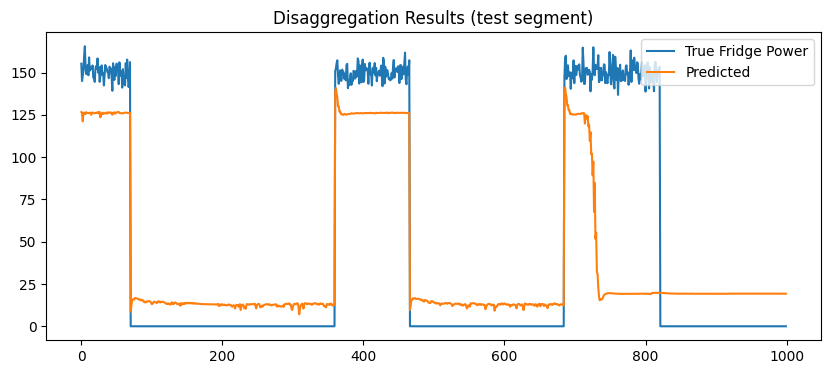

In [13]:
# Plot predictions
plt.figure(figsize=(10,4))
plt.plot(y_true[:1000], label='True Fridge Power')
plt.plot(y_pred[:1000], label='Predicted')
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.title("Disaggregation Results (test segment)"); plt.show()